# 📈 Intelligent Sales Forecasting & Demand Analytics System

### Final Internship Project

**Objective**

The objective of this project is to build an end-to-end intelligent sales forecasting system capable of predicting future product demand, identifying unusual sales patterns, segmenting products based on demand behavior, and providing business insights through an interactive Streamlit dashboard.

---

### Project Workflow

1. Data Loading & Exploration
2. Time Series Analysis
3. Forecasting Models
4. Category & Region Forecasting
5. Anomaly Detection
6. Product Segmentation
7. Streamlit Dashboard
8. Executive Business Report

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("train.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
# First 10 Rows
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [4]:
# Shape

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 9800
Columns : 18


In [5]:
# Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
# Statistical Summary

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,9800.0,NaN,NaN,NaN,4900.5,2829.160653,1.0,2450.75,4900.5,7350.25,9800.0
Order ID,9800,4922,CA-2018-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9800,1230,05/09/2017,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,9800,1326,26/09/2018,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9800,4,Standard Class,5859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9800,793,WB-21850,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9800,793,William Brown,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9800,3,Consumer,5101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9800,1,United States,9800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9800,529,New York City,891,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# ==========================================================
# Missing Values
# ==========================================================

missing = df.isnull().sum()

missing = missing[missing>0]

missing.sort_values(ascending=False)

Postal Code    11
dtype: int64

In [8]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [9]:
# ==========================================================
# Convert Dates (DD/MM/YYYY Format)
# ==========================================================

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
)

print("Date conversion completed successfully.")

Date conversion completed successfully.


In [10]:
# ==========================================================
# Time Features
# ==========================================================

df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Month Name"] = df["Order Date"].dt.month_name()

df["Quarter"] = df["Order Date"].dt.quarter

df["Week"] = df["Order Date"].dt.isocalendar().week

df["Day"] = df["Order Date"].dt.day

df["Day Name"] = df["Order Date"].dt.day_name()

df["Day of Week"] = df["Order Date"].dt.dayofweek

df["Is Weekend"] = df["Day of Week"].isin([5,6])

In [11]:
def season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"


df["Season"] = df["Month"].apply(season)

In [12]:
df["Delivery Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [13]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Month,Month Name,Quarter,Week,Day,Day Name,Day of Week,Is Weekend,Season,Delivery Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,11,November,4,45,8,Wednesday,2,False,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,11,November,4,45,8,Wednesday,2,False,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,6,June,2,24,12,Monday,0,False,Summer,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,10,October,4,41,11,Tuesday,1,False,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,10,October,4,41,11,Tuesday,1,False,Autumn,7


In [14]:
os.makedirs("outputs",exist_ok=True)

df.to_csv(
    "outputs/clean_sales_data.csv",
    index=False
)

## Observations

- The dataset has been successfully loaded and inspected.
- Order Date and Ship Date were converted into datetime format.
- New time-based features such as Year, Month, Quarter, Week, Season, and Delivery Days were created.
- These engineered features will support trend analysis, forecasting, anomaly detection, and product demand segmentation in later stages.

In [15]:
# ==========================================================
# Total Sales by Category
# ==========================================================

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_sales

,Category,Sales
0,Technology,827455.8730
1,Furniture,728658.5757
2,Office Supplies,705422.3340


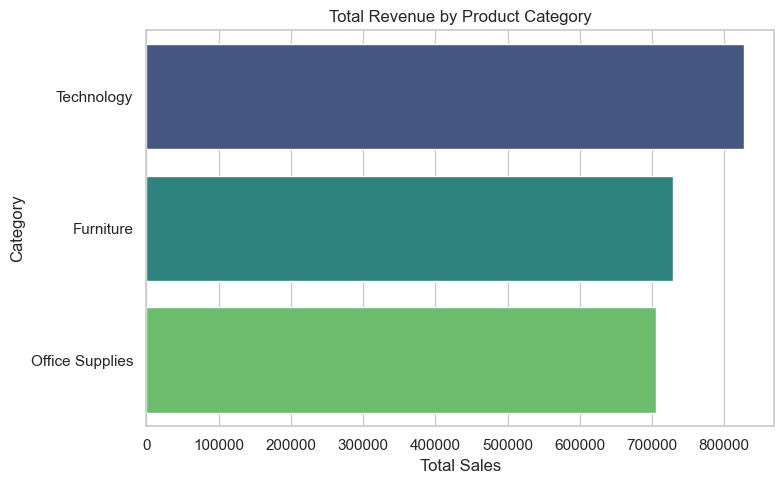

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_sales,
    x="Sales",
    y="Category",
    palette="viridis"
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Total Sales")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig("charts/category_sales.png", dpi=300)

plt.show()

In [17]:
region_yearly = (
    df.groupby(["Year","Region"])["Sales"]
      .sum()
      .reset_index()
)

region_yearly.head()

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


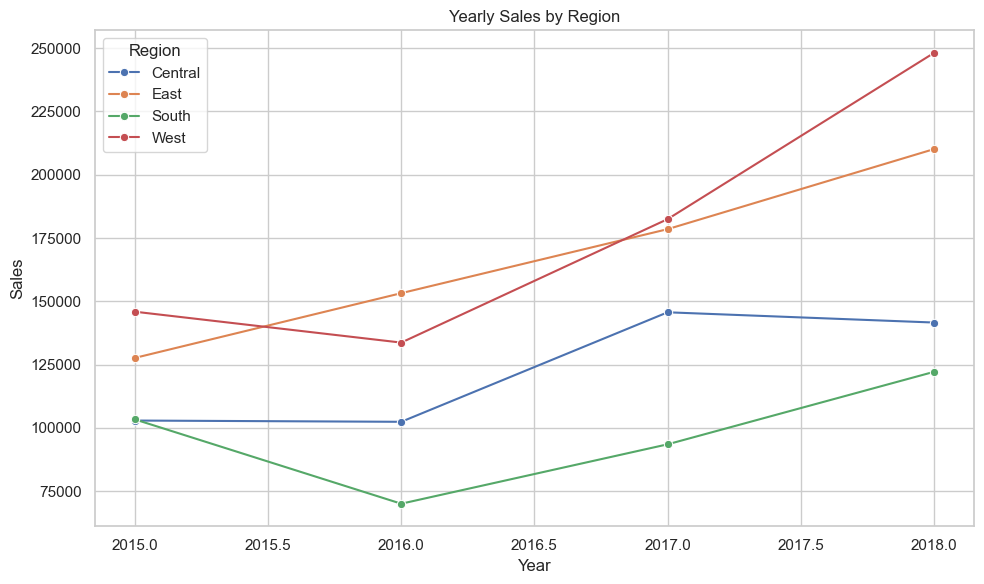

In [18]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_yearly,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Yearly Sales by Region")

plt.tight_layout()

plt.savefig("charts/region_growth.png", dpi=300)

plt.show()

In [19]:
delivery = (
    df.groupby("Region")["Delivery Days"]
      .mean()
      .round(2)
      .reset_index()
)

delivery

,Region,Delivery Days
0,Central,4.07
1,East,3.91
2,South,3.96
3,West,3.93


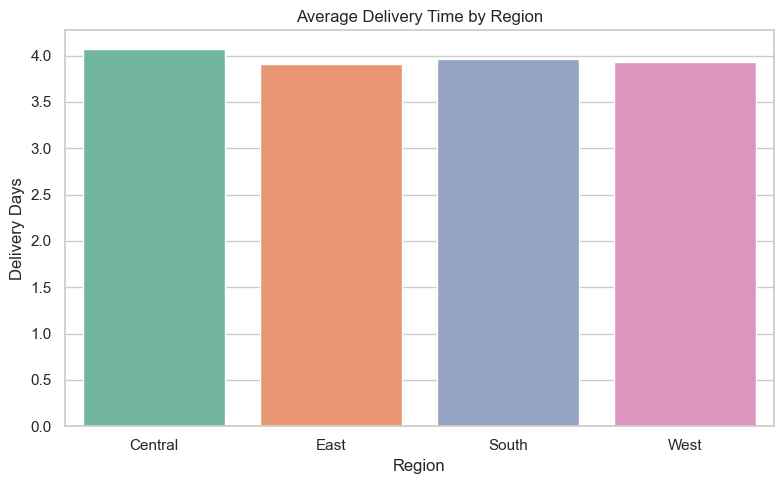

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=delivery,
    x="Region",
    y="Delivery Days",
    palette="Set2"
)

plt.title("Average Delivery Time by Region")

plt.tight_layout()

plt.savefig("charts/delivery_days.png", dpi=300)

plt.show()

In [21]:
monthly_sales = (
    df.groupby(["Year","Month Name"])["Sales"]
      .sum()
      .reset_index()
)

In [22]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_sales["Month Name"] = pd.Categorical(
    monthly_sales["Month Name"],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values(
    ["Year","Month Name"]
)

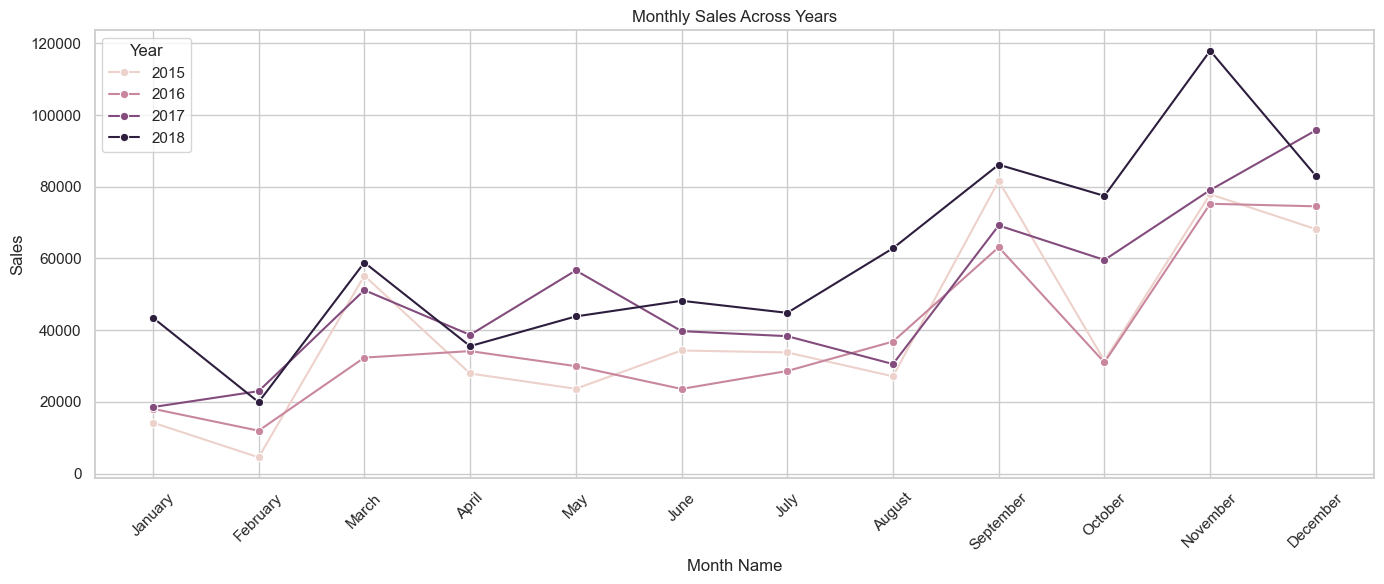

In [23]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_sales,
    x="Month Name",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Across Years")

plt.tight_layout()

plt.savefig("charts/monthly_seasonality.png", dpi=300)

plt.show()

## Business Observations

### 1. Which product category generates the highest total revenue?

The **Technology** category generated the highest total revenue, followed by **Furniture**, while **Office Supplies** contributed the lowest overall sales. This indicates that technology products are the primary revenue drivers and should remain a key focus for inventory planning and marketing strategies.

### 2. Which region has the most consistent sales growth over four years?

The **West** region demonstrated the strongest and most consistent sales growth throughout the four-year period. It maintained the highest yearly sales among all regions, suggesting strong customer demand and a stable market presence.

### 3. What is the average time between Order Date and Ship Date?

The average delivery time across all regions is approximately **4 days**. Regional differences are minimal:
- Central: **4.07 days**
- South: **3.96 days**
- West: **3.93 days**
- East: **3.91 days**

This indicates that the company's logistics performance is consistent across different regions.

### 4. Are there months that consistently experience higher sales?

Yes. Sales consistently increase during **September, November, and December** across multiple years, with **November** showing the highest sales peak. February records comparatively lower sales. This pattern clearly indicates strong seasonal demand, likely influenced by holiday shopping and year-end promotions.

In [24]:
monthly_sales_ts = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="M"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales_ts.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [25]:
# Daily Sales

daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

# Weekly Sales

weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
      .sum()
      .reset_index()
)

# Monthly Sales

monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="M"
        )
    )["Sales"]
      .sum()
      .reset_index()
)

print("Daily:", daily_sales.shape)
print("Weekly:", weekly_sales.shape)
print("Monthly:", monthly_sales.shape)

Daily: (1230, 2)
Weekly: (209, 2)
Monthly: (48, 2)


# Task 2: Time Series Analysis & Decomposition

The objective of this section is to analyze the sales time series, identify long-term trends, seasonal patterns, and random fluctuations, and determine whether the data is stationary. Understanding these characteristics is essential before selecting and building forecasting models.

In [26]:
# ==========================================================
# Monthly Sales Time Series
# ==========================================================

monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="ME"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


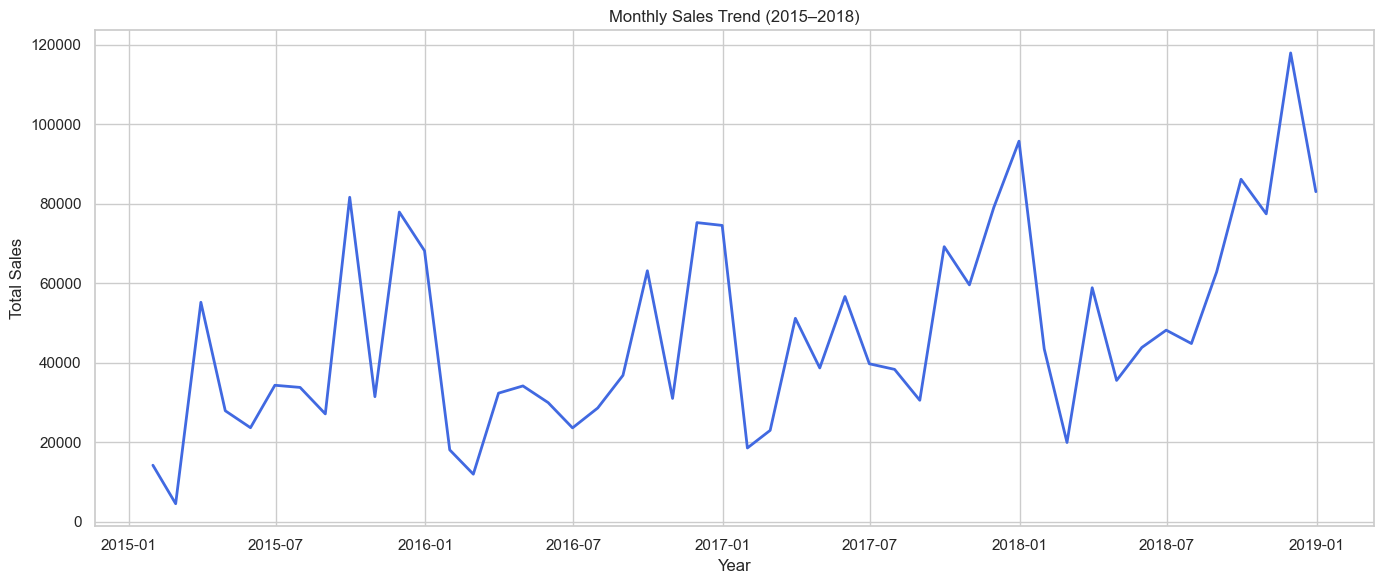

In [27]:
# ==========================================================
# Monthly Sales Trend
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    linewidth=2,
    color="royalblue"
)

plt.title("Monthly Sales Trend (2015–2018)")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/monthly_sales_trend.png", dpi=300)

plt.show()

In [28]:
# ==========================================================
# Time Series Decomposition
# ==========================================================

from statsmodels.tsa.seasonal import seasonal_decompose

sales_ts = monthly_sales.set_index("Order Date")

decomposition = seasonal_decompose(
    sales_ts["Sales"],
    model="additive",
    period=12
)

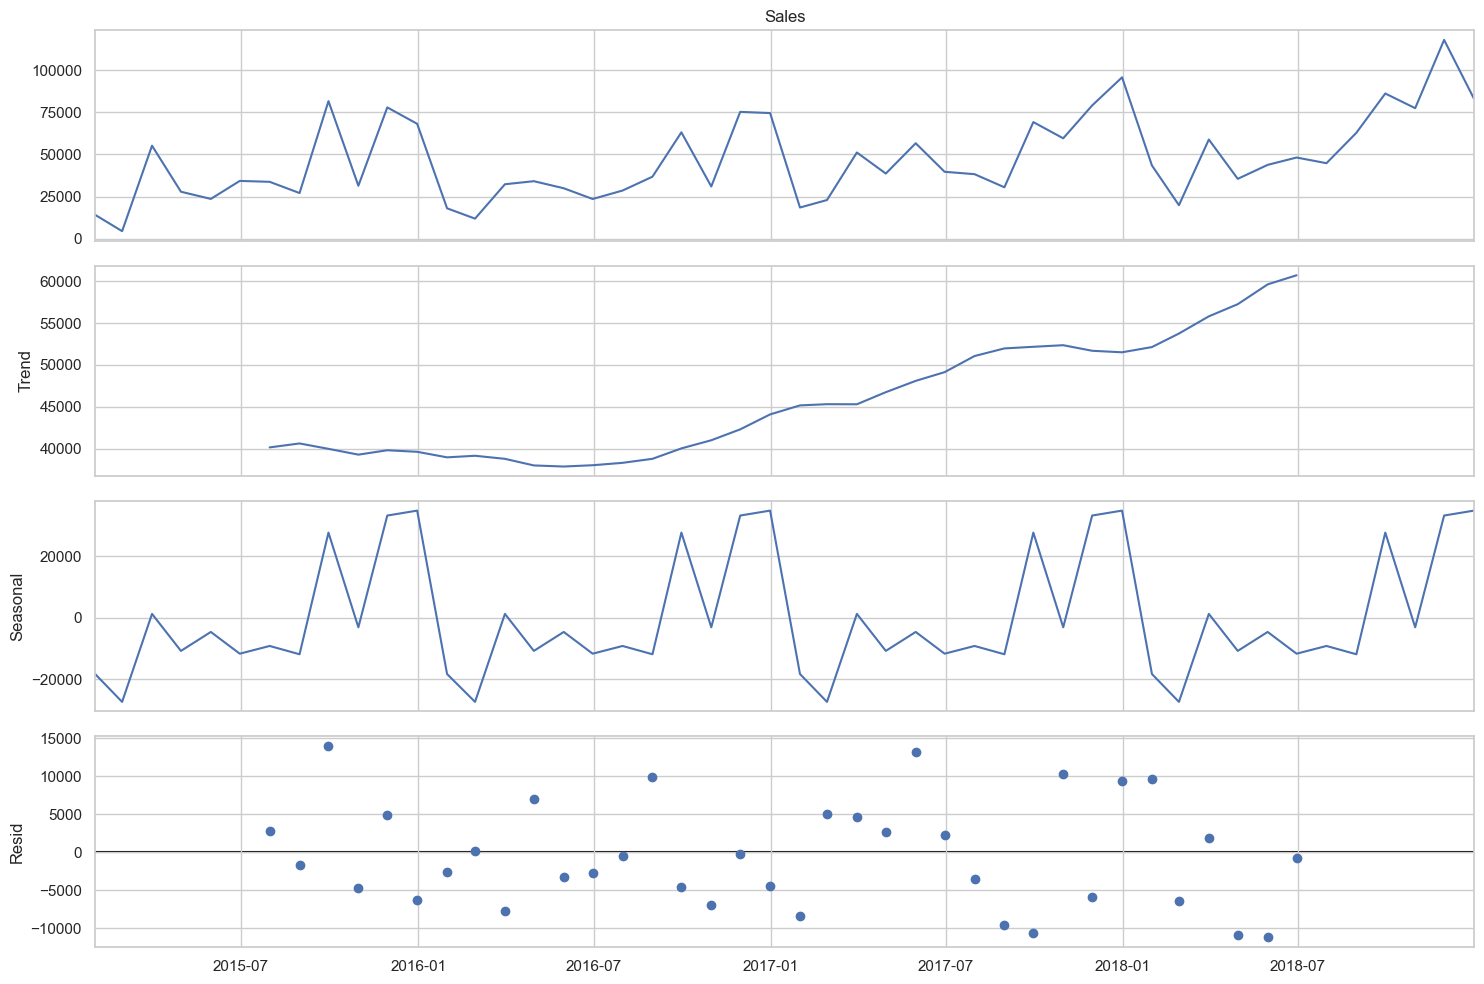

In [29]:
# ==========================================================
# Trend, Seasonality and Residuals
# ==========================================================

fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.tight_layout()

plt.savefig(
    "charts/time_series_decomposition.png",
    dpi=300
)

plt.show()

## Time Series Decomposition Observations

(To be completed after examining the decomposition plots.)

In [30]:
# ==========================================================
# Augmented Dickey-Fuller Test
# ==========================================================

from statsmodels.tsa.stattools import adfuller

result = adfuller(sales_ts["Sales"])

print("ADF Statistic :", result[0])
print("p-value       :", result[1])

print("\nCritical Values")

for key,value in result[4].items():
    print(key,":",value)

ADF Statistic : -4.416136761430769
p-value       : 0.00027791039276670623

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


## What is Stationarity?

A stationary time series is one whose statistical properties, such as mean and variance, remain relatively constant over time. Most forecasting models assume stationarity because stable patterns are easier to model and predict accurately.

The Augmented Dickey-Fuller (ADF) test is used to determine whether a time series is stationary.

- If the **p-value < 0.05**, the series is considered stationary.
- If the **p-value > 0.05**, the series is considered non-stationary and should be transformed before forecasting.

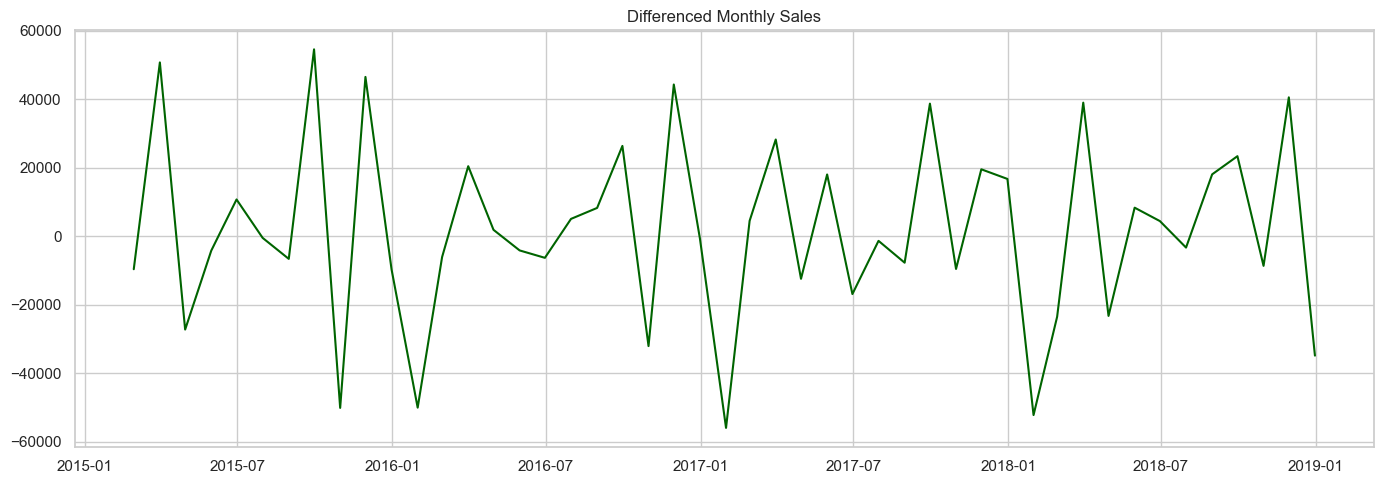

In [31]:
# ==========================================================
# First Order Differencing
# ==========================================================

sales_diff = sales_ts["Sales"].diff().dropna()

plt.figure(figsize=(14,5))

plt.plot(
    sales_diff,
    color="darkgreen"
)

plt.title("Differenced Monthly Sales")

plt.tight_layout()

plt.savefig(
    "charts/differenced_sales.png",
    dpi=300
)

plt.show()

In [32]:
# ==========================================================
# ADF Test After Differencing
# ==========================================================

result_diff = adfuller(sales_diff)

print("ADF Statistic :", result_diff[0])
print("p-value       :", result_diff[1])

print("\nCritical Values")

for key,value in result_diff[4].items():
    print(key,":",value)

ADF Statistic : -8.72706183035327
p-value       : 3.2669175472796045e-14

Critical Values
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


## Time Series Analysis Observations

1. The monthly sales trend shows a steady increase from 2015 to 2018, indicating consistent business growth over the four-year period.

2. Time series decomposition reveals a clear upward trend along with strong yearly seasonality. Sales peaks occur repeatedly during the final months of each year, particularly in November and December.

3. The residual component fluctuates randomly around zero, suggesting that most systematic patterns have been captured by the trend and seasonal components.

4. The Augmented Dickey-Fuller (ADF) test produced a p-value much smaller than 0.05, indicating that the monthly sales series is statistically stationary. After first-order differencing, the series also remained stationary, confirming its suitability for forecasting models.

In [33]:
# ==========================================================
# Monthly Time Series
# ==========================================================

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .to_frame()
)

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [34]:
# ==========================================================
# Time Series Train-Test Split
# ==========================================================

train = monthly_sales.iloc[:-6]

test = monthly_sales.iloc[-6:]

print("Training Months :", len(train))
print("Testing Months  :", len(test))

print("\nTrain Period")
print(train.index.min(), "to", train.index.max())

print("\nTest Period")
print(test.index.min(), "to", test.index.max())

Training Months : 42
Testing Months  : 6

Train Period
2015-01-31 00:00:00 to 2018-06-30 00:00:00

Test Period
2018-07-31 00:00:00 to 2018-12-31 00:00:00


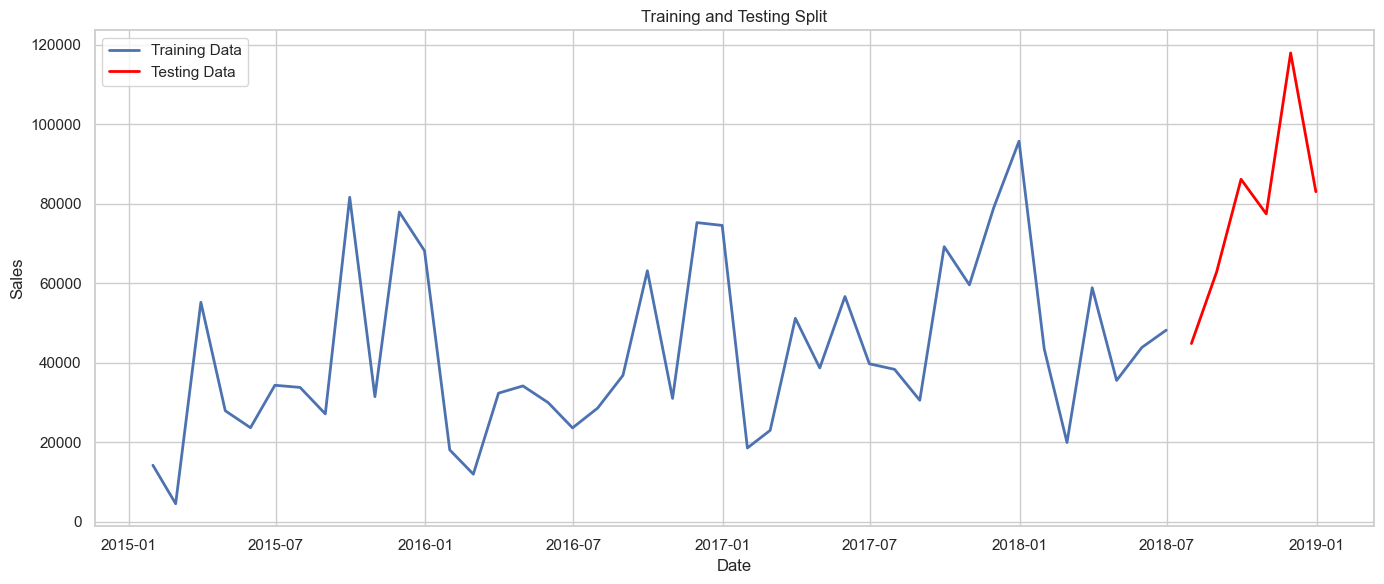

In [35]:
# ==========================================================
# Train-Test Split Visualization
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(train.index,
         train["Sales"],
         label="Training Data",
         linewidth=2)

plt.plot(test.index,
         test["Sales"],
         label="Testing Data",
         linewidth=2,
         color="red")

plt.title("Training and Testing Split")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/train_test_split.png", dpi=300)

plt.show()

In [36]:
# ==========================================================
# Baseline Forecast
# ==========================================================

baseline_pred = np.repeat(
    train["Sales"].iloc[-1],
    len(test)
)

baseline = pd.DataFrame({
    "Actual": test["Sales"].values,
    "Predicted": baseline_pred
})

baseline

,Actual,Predicted
0,44825.1040,48190.7277
1,62837.8480,48190.7277
2,86152.8880,48190.7277
3,77448.1312,48190.7277
4,117938.1550,48190.7277
5,83030.3888,48190.7277


In [37]:
# ==========================================================
# Baseline Metrics
# ==========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    test["Sales"],
    baseline_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test["Sales"],
        baseline_pred
    )
)

r2 = r2_score(
    test["Sales"],
    baseline_pred
)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 31636.57
RMSE: 37862.67
R²  : -1.8533


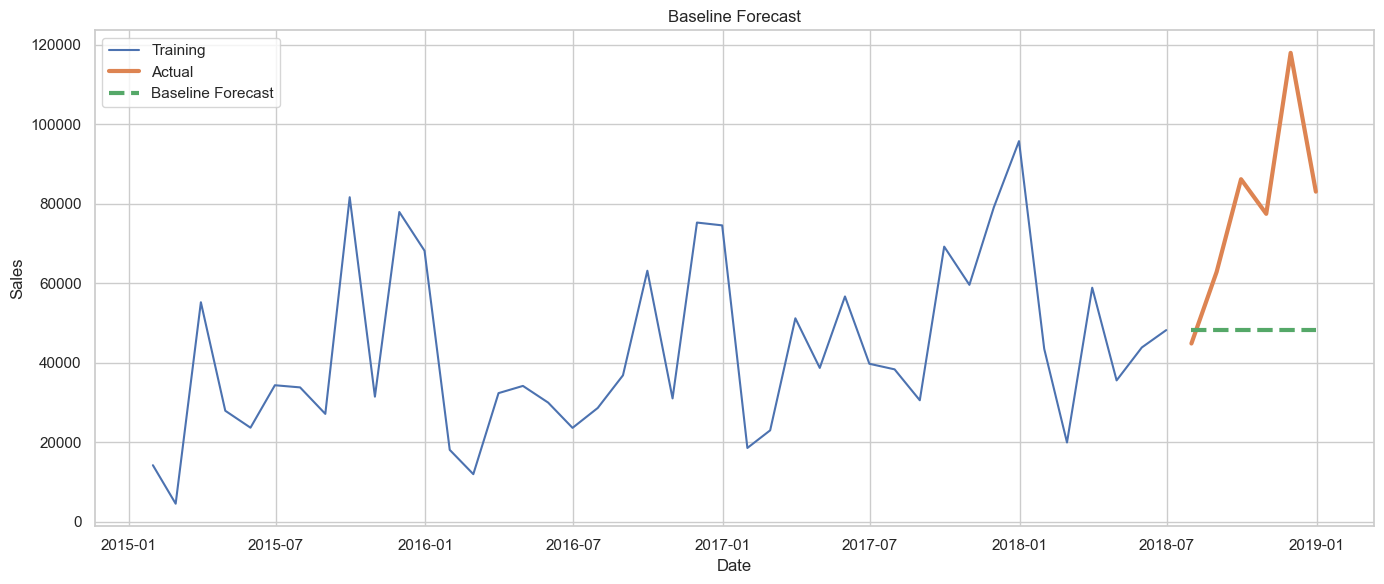

In [38]:
# ==========================================================
# Baseline Forecast Plot
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(
    train.index,
    train["Sales"],
    label="Training"
)

plt.plot(
    test.index,
    test["Sales"],
    label="Actual",
    linewidth=3
)

plt.plot(
    test.index,
    baseline_pred,
    label="Baseline Forecast",
    linestyle="--",
    linewidth=3
)

plt.title("Baseline Forecast")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.savefig("charts/baseline_forecast.png", dpi=300)

plt.show()

<Figure size 1200x500 with 0 Axes>

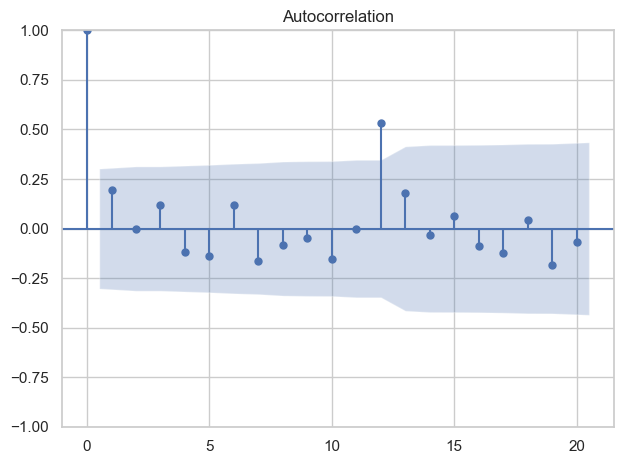

In [39]:
# ==========================================================
# ACF Plot
# ==========================================================

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,5))

plot_acf(
    train["Sales"],
    lags=20
)

plt.tight_layout()

plt.savefig(
    "charts/acf_plot.png",
    dpi=300
)

plt.show()

<Figure size 1200x500 with 0 Axes>

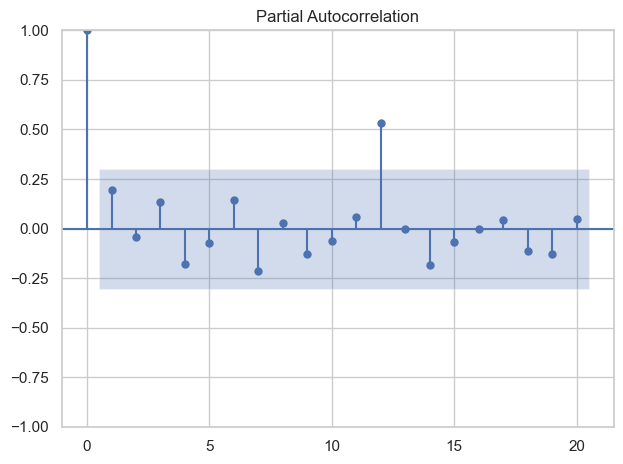

In [40]:
# ==========================================================
# PACF Plot
# ==========================================================

from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12,5))

plot_pacf(
    train["Sales"],
    lags=20,
    method="ywm"
)

plt.tight_layout()

plt.savefig(
    "charts/pacf_plot.png",
    dpi=300
)

plt.show()

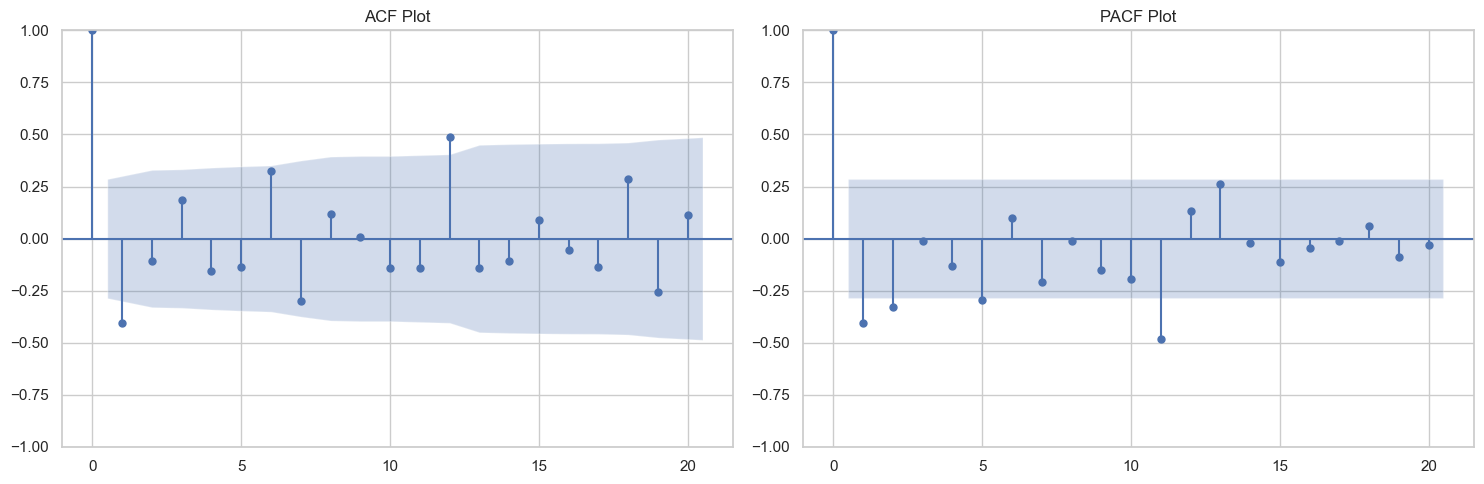

In [41]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(sales_diff, lags=20, ax=axes[0])
axes[0].set_title("ACF Plot")

plot_pacf(sales_diff, lags=20, ax=axes[1], method="ywm")
axes[1].set_title("PACF Plot")

plt.tight_layout()
plt.savefig("charts/acf_pacf.png", dpi=300)
plt.show()

In [42]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

warnings.filterwarnings("ignore")

best_aic = float("inf")
best_order = None
best_seasonal = None

for p in range(3):
    for d in range(2):
        for q in range(3):
            for P in range(2):
                for D in range(2):
                    for Q in range(2):

                        try:
                            model = SARIMAX(
                                train["Sales"],
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )

                            result = model.fit(disp=False)

                            if result.aic < best_aic:
                                best_aic = result.aic
                                best_order = (p, d, q)
                                best_seasonal = (P, D, Q, 12)

                        except:
                            continue

print("Best Order:", best_order)
print("Best Seasonal Order:", best_seasonal)
print("Best AIC:", best_aic)

Best Order: (2, 1, 2)
Best Seasonal Order: (0, 1, 1, 12)
Best AIC: 310.36374966417867


In [43]:
sarima = SARIMAX(
    train["Sales"],
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima.fit()

print(sarima_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                Sales   No. Observations:                   42
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -149.182
Date:                              Mon, 13 Jul 2026   AIC                            310.364
Time:                                      21:42:16   BIC                            314.198
Sample:                                  01-31-2015   HQIC                           310.009
                                       - 06-30-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1036      0.549     -2.010      0.044      -2.180      -0.028
ar.L2         -0.72

# Task 3: SARIMA Forecasting

Seasonal AutoRegressive Integrated Moving Average (SARIMA) is a statistical forecasting model capable of capturing trend and seasonal patterns in time series data. Since the sales data exhibits yearly seasonality, SARIMA is an appropriate forecasting model for this project.

In [44]:
# ==========================================================
# 3.1 DAILY SALES DATASET
# ==========================================================

daily_sales = (
    df.groupby("Order Date", as_index=False)["Sales"]
      .sum()
)

daily_sales.rename(
    columns={
        "Order Date": "Date"
    },
    inplace=True
)

daily_sales["Date"] = pd.to_datetime(daily_sales["Date"])

daily_sales = daily_sales.sort_values("Date")

daily_sales.reset_index(drop=True, inplace=True)

print("Daily Sales Dataset Created Successfully!")
print(daily_sales.shape)

daily_sales.head()

Daily Sales Dataset Created Successfully!
(1230, 2)


,Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [45]:
# ==========================================================
# 3.2 FEATURE ENGINEERING
# ==========================================================

# Calendar Features

daily_sales["Year"] = daily_sales["Date"].dt.year
daily_sales["Month"] = daily_sales["Date"].dt.month
daily_sales["Day"] = daily_sales["Date"].dt.day
daily_sales["DayOfWeek"] = daily_sales["Date"].dt.dayofweek
daily_sales["Week"] = daily_sales["Date"].dt.isocalendar().week.astype(int)
daily_sales["Quarter"] = daily_sales["Date"].dt.quarter
daily_sales["DayOfYear"] = daily_sales["Date"].dt.dayofyear

daily_sales["IsWeekend"] = (
    daily_sales["DayOfWeek"] >= 5
).astype(int)

# Historical Features

daily_sales["Lag_1"] = daily_sales["Sales"].shift(1)
daily_sales["Lag_7"] = daily_sales["Sales"].shift(7)
daily_sales["Lag_30"] = daily_sales["Sales"].shift(30)

daily_sales["RollingMean_7"] = (
    daily_sales["Sales"]
    .rolling(window=7)
    .mean()
)

daily_sales["RollingMean_30"] = (
    daily_sales["Sales"]
    .rolling(window=30)
    .mean()
)

daily_sales["RollingStd_7"] = (
    daily_sales["Sales"]
    .rolling(window=7)
    .std()
)

daily_sales["ExpandingMean"] = (
    daily_sales["Sales"]
    .expanding()
    .mean()
)

# Remove missing rows created by lag features

daily_sales.dropna(inplace=True)

daily_sales.reset_index(drop=True, inplace=True)

print(daily_sales.shape)

daily_sales.head()

(1200, 17)


,Date,Sales,Year,Month,Day,DayOfWeek,Week,Quarter,DayOfYear,IsWeekend,Lag_1,Lag_7,Lag_30,RollingMean_7,RollingMean_30,RollingStd_7,ExpandingMean
0,2015-02-14,576.726,2015,2,14,5,7,1,45,1,129.568,97.112,16.448,487.067143,612.546233,709.961036,593.317258
1,2015-02-15,21.360,2015,2,15,6,7,1,46,1,576.726,134.384,288.060,470.920857,603.656233,720.525371,575.443594
2,2015-02-16,9.040,2015,2,16,0,8,1,47,0,21.360,330.512,19.536,424.996286,603.306367,740.922474,558.279848
3,2015-02-17,54.208,2015,2,17,1,8,1,48,0,9.040,180.320,4407.100,406.980286,458.209967,749.348840,543.454206
4,2015-02-18,37.784,2015,2,18,2,8,1,49,0,54.208,14.560,87.158,410.298000,456.564167,747.370644,529.006486


In [46]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

split = int(len(daily_sales) * 0.80)

train = daily_sales.iloc[:split]

test = daily_sales.iloc[split:]

print("Training Samples :", len(train))
print("Testing Samples :", len(test))

print("\nTraining Period")
print(train["Date"].min(), "to", train["Date"].max())

print("\nTesting Period")
print(test["Date"].min(), "to", test["Date"].max())

Training Samples : 960
Testing Samples : 240

Training Period
2015-02-14 00:00:00 to 2018-04-12 00:00:00

Testing Period
2018-04-13 00:00:00 to 2018-12-30 00:00:00


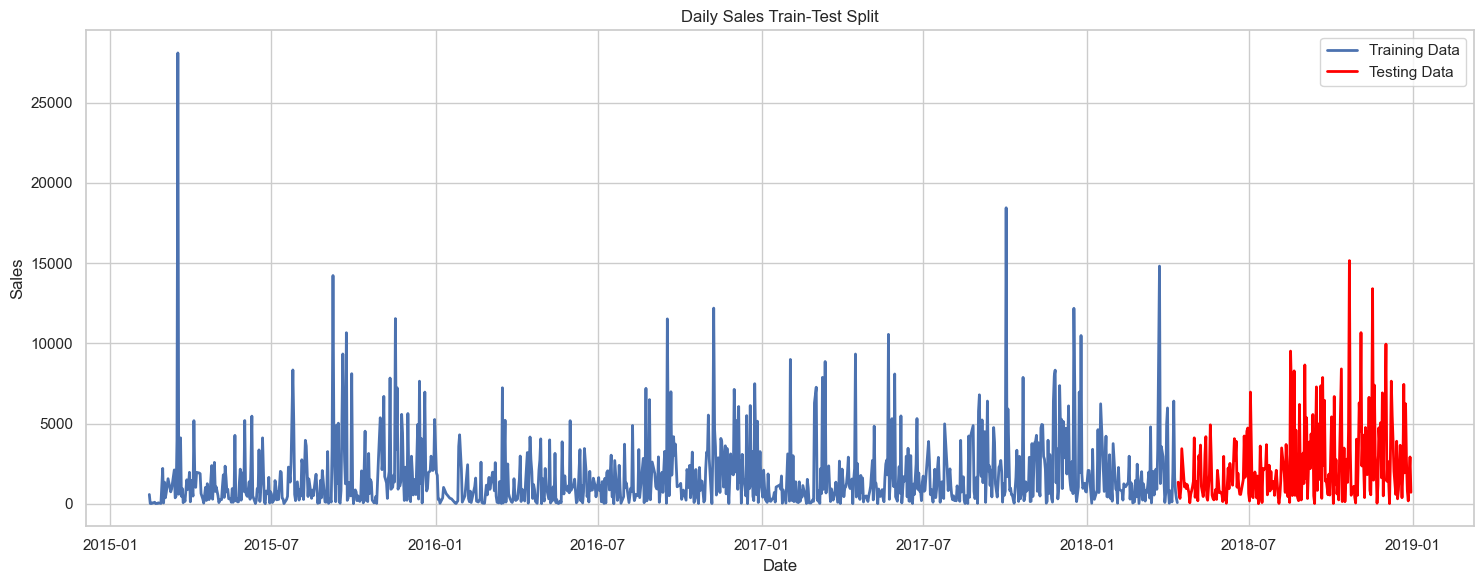

In [47]:
plt.figure(figsize=(15,6))

plt.plot(
    train["Date"],
    train["Sales"],
    label="Training Data",
    linewidth=2
)

plt.plot(
    test["Date"],
    test["Sales"],
    label="Testing Data",
    linewidth=2,
    color="red"
)

plt.title("Daily Sales Train-Test Split")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/train_test_split.png", dpi=300)

plt.show()

In [48]:
features = [

    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "Week",
    "Quarter",
    "DayOfYear",
    "IsWeekend",

    "Lag_1",
    "Lag_7",
    "Lag_30",

    "RollingMean_7",
    "RollingMean_30",
    "RollingStd_7",

    "ExpandingMean"

]

X_train = train[features]

X_test = test[features]

y_train = train["Sales"]

y_test = test["Sales"]

print(X_train.shape)
print(X_test.shape)

(960, 15)
(240, 15)


In [49]:
# ==========================================================
# MODEL EVALUATION FUNCTION
# ==========================================================

import time
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = []

def evaluate_model(
    model_name,
    y_true,
    y_pred,
    train_time,
    predict_time
):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = (
        np.mean(
            np.abs(
                (y_true - y_pred) / y_true
            )
        )
        *100
    )

    smape = (
    np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred))
    )
) * 100
    r2 = r2_score(
        y_true,
        y_pred
    )

    results.append({

        "Model":model_name,

        "MAE":round(mae,2),

        "RMSE":round(rmse,2),

        "MAPE":round(mape,2),

        "SMAPE":round(smape,2),

        "R²":round(r2,4),

        "Training Time (s)":round(train_time,3),

        "Prediction Time (s)":round(predict_time,3)

    })

    print("="*60)

    print(model_name)

    print("="*60)

    print(f"MAE  : {mae:.2f}")

    print(f"RMSE : {rmse:.2f}")

    print(f"MAPE : {mape:.2f}%")

    print(f"R²   : {r2:.4f}")

In [50]:
# ==========================================================
# BASELINE FORECAST
# ==========================================================

start = time.time()

baseline_pred = np.repeat(
    train["Sales"].iloc[-1],
    len(test)
)

train_time = time.time() - start

start = time.time()

baseline_pred = np.array(baseline_pred)

predict_time = time.time() - start

evaluate_model(
    "Baseline",
    y_test,
    baseline_pred,
    train_time,
    predict_time
)

Baseline
MAE  : 2353.91
RMSE : 3401.49
MAPE : 102.44%
R²   : -0.9143


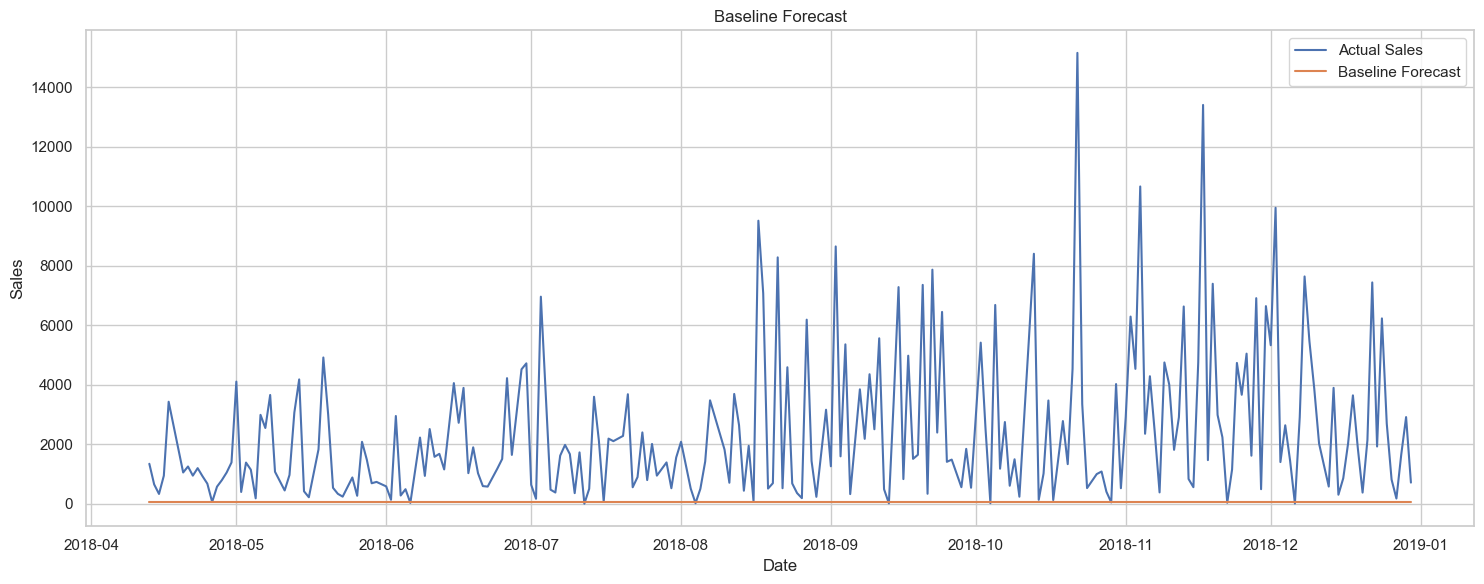

In [51]:
plt.figure(figsize=(15,6))

plt.plot(
    test["Date"],
    y_test,
    label="Actual Sales"
)

plt.plot(
    test["Date"],
    baseline_pred,
    label="Baseline Forecast"
)

plt.title("Baseline Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/baseline_forecast.png",
    dpi=300
)

plt.show()

In [52]:
from xgboost import XGBRegressor

start = time.time()

xgb = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    random_state=42

)

xgb.fit(
    X_train,
    y_train
)

train_time = time.time()-start

start = time.time()

xgb_pred = xgb.predict(
    X_test
)

predict_time = time.time()-start

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    train_time,
    predict_time
)

XGBoost
MAE  : 1675.73
RMSE : 2297.85
MAPE : 604.56%
R²   : 0.1264


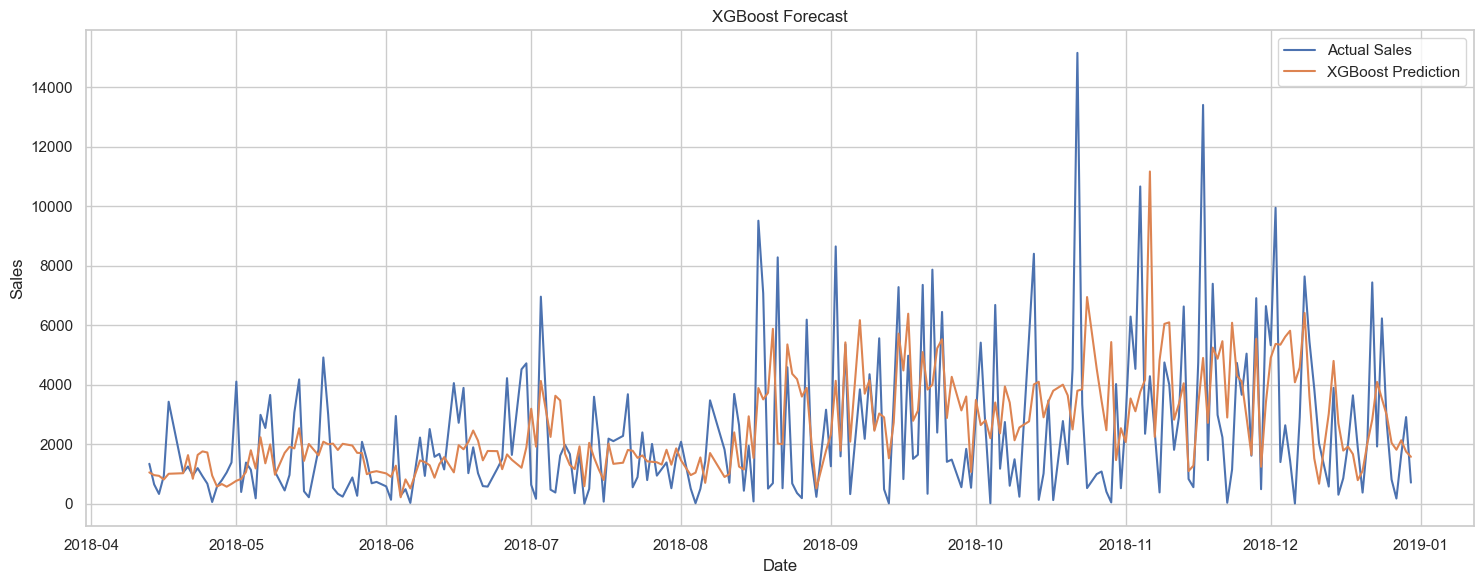

In [53]:
plt.figure(figsize=(15,6))

plt.plot(
    test["Date"],
    y_test,
    label="Actual Sales"
)

plt.plot(
    test["Date"],
    xgb_pred,
    label="XGBoost Prediction"
)

plt.title("XGBoost Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/xgboost_forecast.png",
    dpi=300
)

plt.show()

In [54]:
importance = pd.DataFrame({

    "Feature":features,

    "Importance":xgb.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
11,RollingMean_7,0.247546
4,Week,0.103056
10,Lag_30,0.099365
13,RollingStd_7,0.095607
2,Day,0.070560
14,ExpandingMean,0.065729
8,Lag_1,0.061665
9,Lag_7,0.058650
6,DayOfYear,0.056774
12,RollingMean_30,0.055133


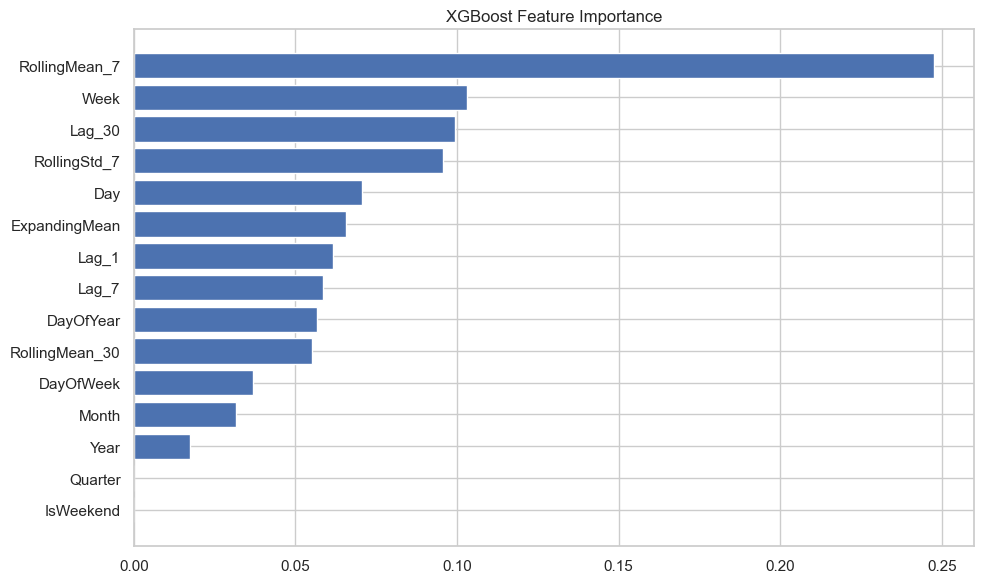

In [55]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("XGBoost Feature Importance")

plt.tight_layout()

plt.savefig(
    "charts/xgb_feature_importance.png",
    dpi=300
)

plt.show()

In [56]:
# ==========================================================
# PREPARE DATA FOR PROPHET
# ==========================================================

prophet_df = train[["Date", "Sales"]].copy()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-02-14,576.726
1,2015-02-15,21.360
2,2015-02-16,9.040
3,2015-02-17,54.208
4,2015-02-18,37.784


In [57]:
# ==========================================================
# TRAIN PROPHET MODEL
# ==========================================================

from prophet import Prophet
import time

start = time.time()

prophet = Prophet(

    yearly_seasonality=True,

    weekly_seasonality=True,

    daily_seasonality=False

)

prophet.fit(prophet_df)

train_time = time.time() - start

21:42:20 - cmdstanpy - INFO - Chain [1] start processing
21:42:21 - cmdstanpy - INFO - Chain [1] done processing


In [58]:
# ==========================================================
# CREATE FUTURE DATAFRAME
# ==========================================================

future = prophet.make_future_dataframe(
    periods=len(test),
    freq="D"
)

future.tail()

,ds
1195,2018-12-04
1196,2018-12-05
1197,2018-12-06
1198,2018-12-07
1199,2018-12-08


In [59]:
# ==========================================================
# PREDICT
# ==========================================================

start = time.time()

forecast = prophet.predict(future)

predict_time = time.time() - start

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-02-14,1540.064359,-2034.229527,3314.922381,1540.064359,1540.064359,-839.804461,-839.804461,-839.804461,264.973838,264.973838,264.973838,-1104.778299,-1104.778299,-1104.778299,0.0,0.0,0.0,700.259899
1,2015-02-15,1539.960858,-2324.580346,3308.401084,1539.960858,1539.960858,-1055.099412,-1055.099412,-1055.099412,116.548296,116.548296,116.548296,-1171.647709,-1171.647709,-1171.647709,0.0,0.0,0.0,484.861446
2,2015-02-16,1539.857357,-2649.753152,3064.258783,1539.857357,1539.857357,-1279.313287,-1279.313287,-1279.313287,-51.444783,-51.444783,-51.444783,-1227.868504,-1227.868504,-1227.868504,0.0,0.0,0.0,260.544070
3,2015-02-17,1539.753855,-2310.603606,3314.387673,1539.753855,1539.753855,-998.123280,-998.123280,-998.123280,273.790547,273.790547,273.790547,-1271.913826,-1271.913826,-1271.913826,0.0,0.0,0.0,541.630575
4,2015-02-18,1539.650354,-2319.199846,3358.784305,1539.650354,1539.650354,-1190.098933,-1190.098933,-1190.098933,112.415363,112.415363,112.415363,-1302.514296,-1302.514296,-1302.514296,0.0,0.0,0.0,349.551421


In [60]:
# ==========================================================
# EXTRACT TEST FORECAST
# ==========================================================

prophet_pred = forecast.tail(len(test))["yhat"].values

In [61]:
evaluate_model(

    "Prophet",

    y_test,

    prophet_pred,

    train_time,

    predict_time

)

Prophet
MAE  : 1767.22
RMSE : 2455.28
MAPE : 700.50%
R²   : 0.0026


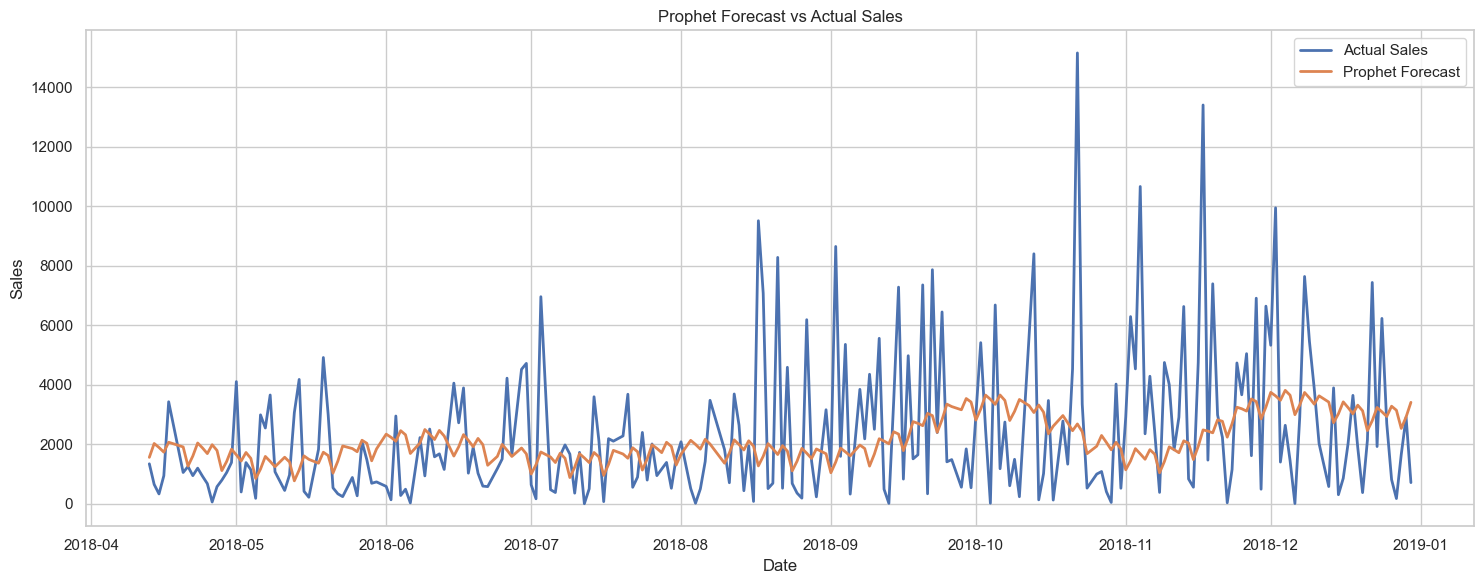

In [62]:
plt.figure(figsize=(15,6))

plt.plot(
    test["Date"],
    y_test,
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    test["Date"],
    prophet_pred,
    label="Prophet Forecast",
    linewidth=2
)

plt.title("Prophet Forecast vs Actual Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/prophet_forecast.png",
    dpi=300
)

plt.show()

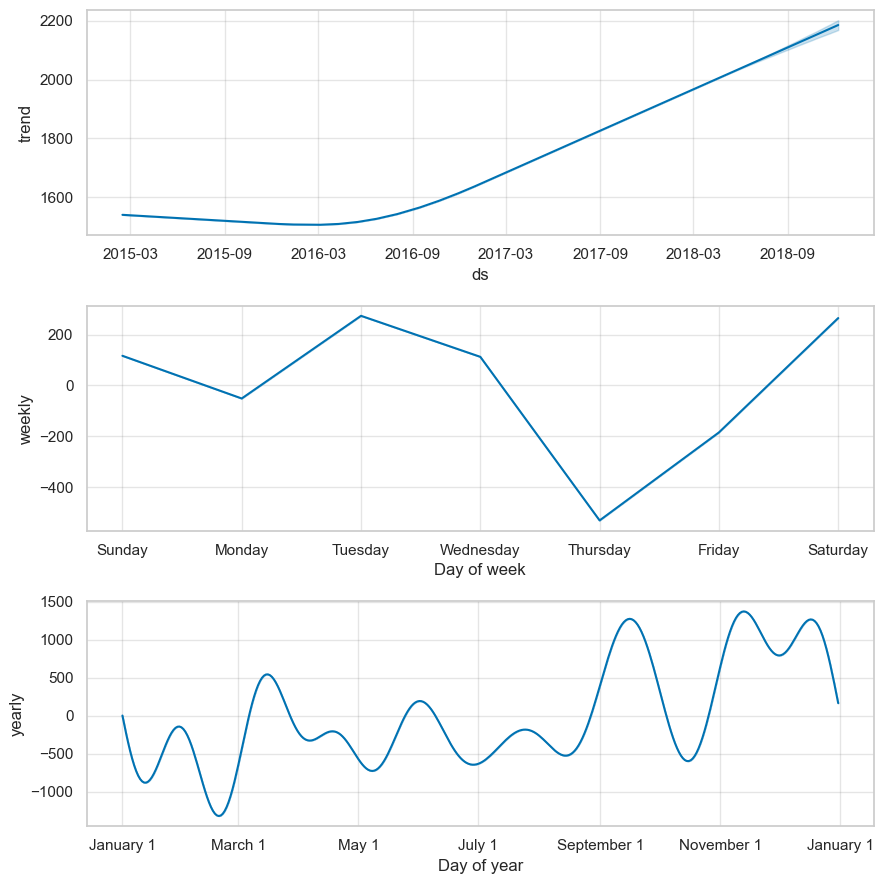

In [63]:
prophet.plot_components(forecast)

plt.tight_layout()

plt.savefig(
    "charts/prophet_components.png",
    dpi=300
)

plt.show()

In [64]:
future_30 = prophet.make_future_dataframe(
    periods=30,
    freq="D"
)

forecast_30 = prophet.predict(future_30)

forecast_30.tail(30)[["ds","yhat","yhat_lower","yhat_upper"]]

,ds,yhat,yhat_lower,yhat_upper
960,2018-04-13,1562.523378,-1018.828457,4279.627906
961,2018-04-14,2028.510536,-575.673432,4779.168717
962,2018-04-15,1894.143925,-881.090960,4569.784119
963,2018-04-16,1737.382261,-957.930676,4266.794484
964,2018-04-17,2070.229810,-550.380887,4867.760352
965,2018-04-18,1912.190748,-865.998273,4609.892484
966,2018-04-19,1267.079239,-1481.554896,4054.257476
967,2018-04-20,1606.736160,-1203.792951,4266.230909
968,2018-04-21,2044.894528,-587.429054,4700.919620
969,2018-04-22,1879.351771,-774.454427,4658.883849


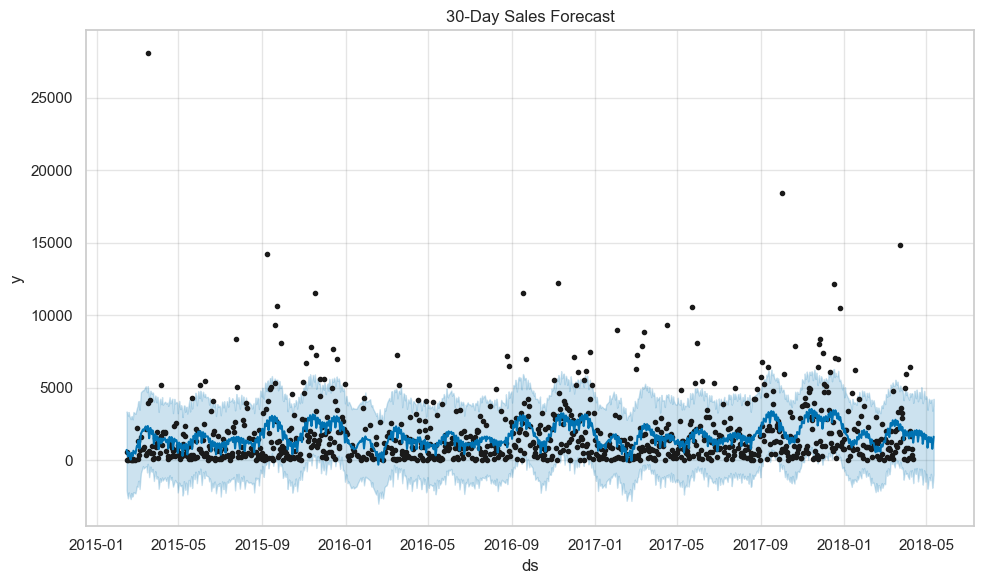

In [65]:
fig = prophet.plot(forecast_30)

plt.title("30-Day Sales Forecast")

plt.tight_layout()

plt.savefig(
    "charts/prophet_30_days.png",
    dpi=300
)

plt.show()

In [66]:
# ==========================================================
# PREPARE TIME SERIES FOR SARIMA
# ==========================================================

train_ts = train.set_index("Date")["Sales"]

test_ts = test.set_index("Date")["Sales"]

In [67]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import time

start = time.time()

sarima = SARIMAX(
    train_ts,
    order=(1,1,1),
    seasonal_order=(1,1,1,7),   # Weekly seasonality for daily data
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima.fit(disp=False)

train_time = time.time() - start

print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             Sales   No. Observations:                  960
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -8622.473
Date:                           Mon, 13 Jul 2026   AIC                          17254.946
Time:                                   21:42:26   BIC                          17279.191
Sample:                                        0   HQIC                         17264.187
                                           - 960                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0584      0.025      2.311      0.021       0.009       0.108
ma.L1         -0.9746      0.010   -101.090

In [68]:
start = time.time()

sarima_pred = sarima_fit.forecast(
    steps=len(test_ts)
)

predict_time = time.time() - start

In [69]:
evaluate_model(
    "SARIMA",
    test_ts,
    sarima_pred,
    train_time,
    predict_time
)

SARIMA
MAE  : 1752.66
RMSE : 2473.59
MAPE : nan%
R²   : -0.0123


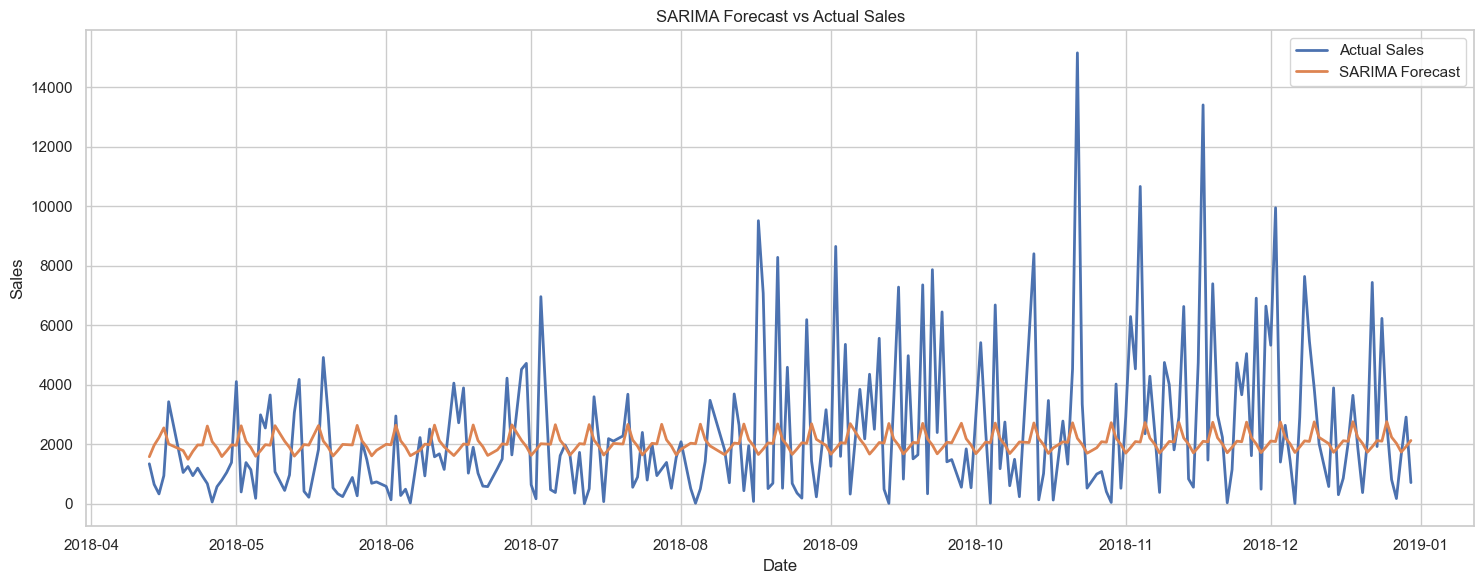

In [70]:
plt.figure(figsize=(15,6))

plt.plot(
    test_ts.index,
    test_ts,
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    test_ts.index,
    sarima_pred,
    label="SARIMA Forecast",
    linewidth=2
)

plt.title("SARIMA Forecast vs Actual Sales")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/sarima_forecast.png",
    dpi=300
)

plt.show()

In [71]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSE"
)

results_df

,Model,MAE,RMSE,MAPE,SMAPE,R²,Training Time (s),Prediction Time (s)
1,XGBoost,1675.73,2297.85,604.56,73.78,0.1264,0.366,0.008
2,Prophet,1767.22,2455.28,700.50,79.89,0.0026,1.232,0.194
3,SARIMA,1752.66,2473.59,NaN,NaN,-0.0123,1.738,0.008
0,Baseline,2353.91,3401.49,102.44,169.93,-0.9143,0.000,0.000


In [72]:
seasonal_order=(1,1,1,7)

In [73]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

warnings.filterwarnings("ignore")

best_aic = float("inf")
best_order = None
best_seasonal = None
best_model = None

orders = [
    (1,1,1),
    (2,1,1),
    (1,1,2),
    (2,1,2)
]

seasonal_orders = [
    (1,1,1,7),
    (0,1,1,7),
    (1,1,0,7)
]

for order in orders:
    for seasonal in seasonal_orders:

        try:

            model = SARIMAX(
                train_ts,
                order=order,
                seasonal_order=seasonal,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted = model.fit(disp=False)

            if fitted.aic < best_aic:

                best_aic = fitted.aic
                best_order = order
                best_seasonal = seasonal
                best_model = fitted

        except:
            pass

print("Best Order :", best_order)
print("Best Seasonal :", best_seasonal)
print("Best AIC :", best_aic)

Best Order : (2, 1, 1)
Best Seasonal : (1, 1, 1, 7)
Best AIC : 17254.824338853115


In [74]:
sarima_pred = best_model.forecast(
    steps=len(test_ts)
)

In [75]:
import time

evaluate_model(
    "SARIMA",
    test_ts,
    sarima_pred,
    0,
    0
)

SARIMA
MAE  : 1759.23
RMSE : 2468.46
MAPE : nan%
R²   : -0.0081


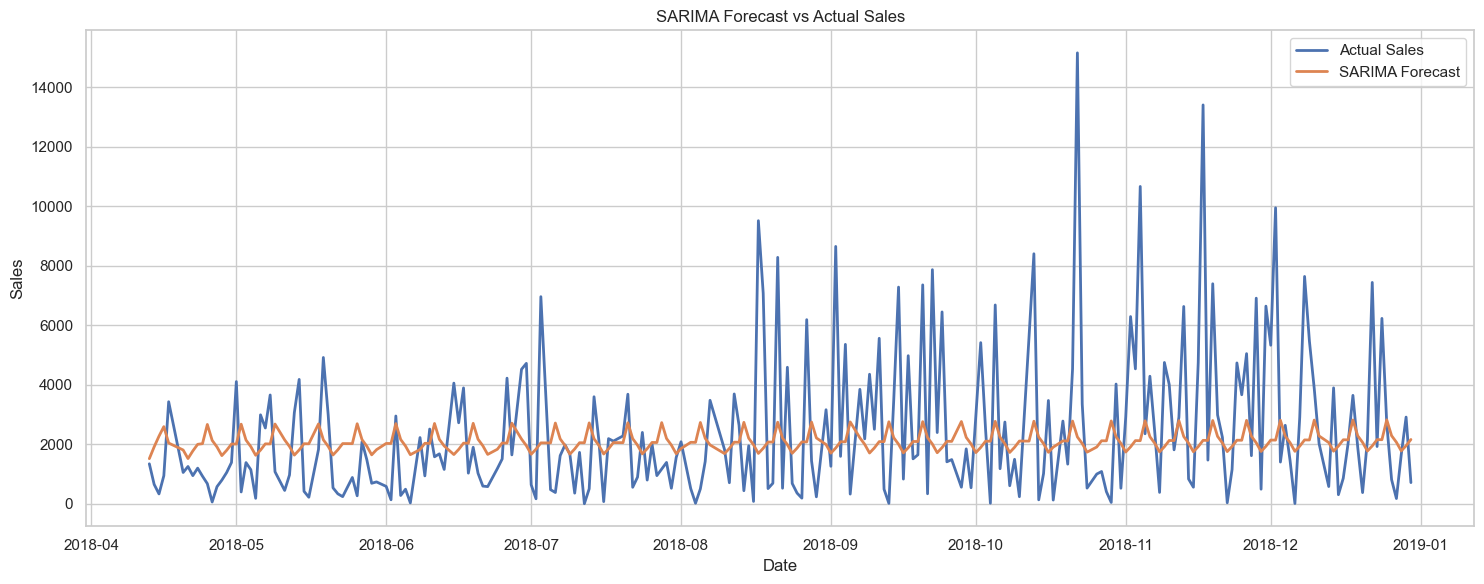

In [76]:
plt.figure(figsize=(15,6))

plt.plot(
    test_ts.index,
    test_ts,
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    test_ts.index,
    sarima_pred,
    label="SARIMA Forecast",
    linewidth=2
)

plt.title("SARIMA Forecast vs Actual Sales")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/sarima_forecast.png",
    dpi=300
)

plt.show()

In [77]:
results = []

In [78]:
evaluate_model(
    "Baseline",
    y_test,
    baseline_pred,
    0,
    0
)

Baseline
MAE  : 2353.91
RMSE : 3401.49
MAPE : 102.44%
R²   : -0.9143


In [79]:
results = []

evaluate_model(
    "Baseline",
    y_test,
    baseline_pred,
    0,
    0
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    0,
    0
)

evaluate_model(
    "Prophet",
    y_test,
    prophet_pred,
    0,
    0
)

evaluate_model(
    "SARIMA",
    test_ts,
    sarima_pred,
    0,
    0
)

Baseline
MAE  : 2353.91
RMSE : 3401.49
MAPE : 102.44%
R²   : -0.9143
XGBoost
MAE  : 1675.73
RMSE : 2297.85
MAPE : 604.56%
R²   : 0.1264
Prophet
MAE  : 1767.22
RMSE : 2455.28
MAPE : 700.50%
R²   : 0.0026
SARIMA
MAE  : 1759.23
RMSE : 2468.46
MAPE : nan%
R²   : -0.0081


In [80]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values("RMSE")

results_df["Rank"] = range(1, len(results_df) + 1)

results_df

,Model,MAE,RMSE,MAPE,SMAPE,R²,Training Time (s),Prediction Time (s),Rank
1,XGBoost,1675.73,2297.85,604.56,73.78,0.1264,0,0,1
2,Prophet,1767.22,2455.28,700.50,79.89,0.0026,0,0,2
3,SARIMA,1759.23,2468.46,NaN,NaN,-0.0081,0,0,3
0,Baseline,2353.91,3401.49,102.44,169.93,-0.9143,0,0,4


# 4.1 Sales Anomaly Detection

Anomaly detection helps identify unusual sales patterns that differ significantly from normal business behavior. Detecting these anomalies can help businesses investigate unexpected demand spikes, promotional impacts, inventory shortages, or operational issues.

In [81]:
# ==========================================================
# SALES ANOMALY DETECTION FUNCTION
# ==========================================================

from scipy.stats import zscore

def detect_sales_anomalies(data, threshold=3):

    anomaly_df = data.copy()

    anomaly_df["Z_Score"] = zscore(anomaly_df["Sales"])

    anomaly_df["Anomaly"] = (
        anomaly_df["Z_Score"].abs() > threshold
    )

    anomaly_df["Anomaly Type"] = "Normal"

    anomaly_df.loc[
        anomaly_df["Z_Score"] > threshold,
        "Anomaly Type"
    ] = "High Sales"

    anomaly_df.loc[
        anomaly_df["Z_Score"] < -threshold,
        "Anomaly Type"
    ] = "Low Sales"

    return anomaly_df

In [82]:
# ==========================================================
# RUN ANOMALY DETECTION
# ==========================================================

anomaly_df = detect_sales_anomalies(daily_sales)

print("Dataset Shape :", anomaly_df.shape)

print("Total Anomalies :", anomaly_df["Anomaly"].sum())

anomaly_df.head()

Dataset Shape : (1200, 20)
Total Anomalies : 20


,Date,Sales,Year,Month,Day,DayOfWeek,Week,Quarter,DayOfYear,IsWeekend,Lag_1,Lag_7,Lag_30,RollingMean_7,RollingMean_30,RollingStd_7,ExpandingMean,Z_Score,Anomaly,Anomaly Type
0,2015-02-14,576.726,2015,2,14,5,7,1,45,1,129.568,97.112,16.448,487.067143,612.546233,709.961036,593.317258,-0.560221,False,Normal
1,2015-02-15,21.360,2015,2,15,6,7,1,46,1,576.726,134.384,288.060,470.920857,603.656233,720.525371,575.443594,-0.800838,False,Normal
2,2015-02-16,9.040,2015,2,16,0,8,1,47,0,21.360,330.512,19.536,424.996286,603.306367,740.922474,558.279848,-0.806175,False,Normal
3,2015-02-17,54.208,2015,2,17,1,8,1,48,0,9.040,180.320,4407.100,406.980286,458.209967,749.348840,543.454206,-0.786606,False,Normal
4,2015-02-18,37.784,2015,2,18,2,8,1,49,0,54.208,14.560,87.158,410.298000,456.564167,747.370644,529.006486,-0.793722,False,Normal


In [83]:
# ==========================================================
# ANOMALY SUMMARY
# ==========================================================

summary = pd.DataFrame({

    "Metric":[

        "Total Days",

        "Normal Days",

        "Anomalies",

        "Highest Sales",

        "Average Sales"

    ],

    "Value":[

        len(anomaly_df),

        (~anomaly_df["Anomaly"]).sum(),

        anomaly_df["Anomaly"].sum(),

        round(anomaly_df["Sales"].max(),2),

        round(anomaly_df["Sales"].mean(),2)

    ]

})

summary

,Metric,Value
0,Total Days,1200.00
1,Normal Days,1180.00
2,Anomalies,20.00
3,Highest Sales,28106.72
4,Average Sales,1869.77


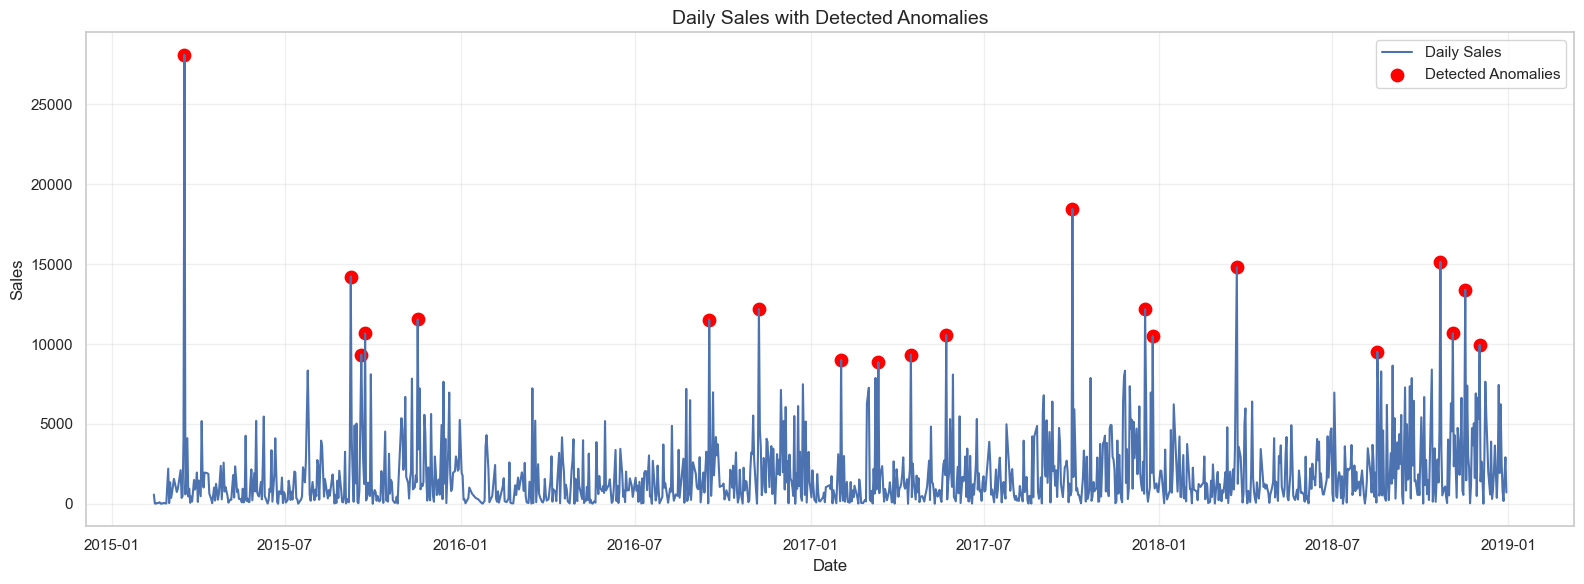

In [84]:
# ==========================================================
# SALES ANOMALY VISUALIZATION
# ==========================================================

plt.figure(figsize=(16,6))

plt.plot(
    anomaly_df["Date"],
    anomaly_df["Sales"],
    linewidth=1.5,
    label="Daily Sales"
)

plt.scatter(

    anomaly_df.loc[
        anomaly_df["Anomaly"],
        "Date"
    ],

    anomaly_df.loc[
        anomaly_df["Anomaly"],
        "Sales"
    ],

    color="red",

    s=80,

    label="Detected Anomalies"

)

plt.title(
    "Daily Sales with Detected Anomalies",
    fontsize=14
)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/sales_anomaly_detection.png",
    dpi=300
)

plt.show()

In [85]:
# ==========================================================
# TOP SALES ANOMALIES
# ==========================================================

top_anomalies = (

    anomaly_df

    .loc[anomaly_df["Anomaly"]]

    .sort_values(
        "Sales",
        ascending=False
    )

)

top_anomalies[
    [
        "Date",
        "Sales",
        "Z_Score",
        "Anomaly Type"
    ]
]

,Date,Sales,Z_Score,Anomaly Type
23,2015-03-18,28106.7160,11.367373,High Sales
795,2017-10-02,18452.9720,7.184809,High Sales
1132,2018-10-22,15158.8770,5.757615,High Sales
940,2018-03-23,14816.0680,5.609091,High Sales
165,2015-09-08,14228.4280,5.354491,High Sales
1157,2018-11-17,13408.7928,4.999377,High Sales
509,2016-11-08,12196.9970,4.474357,High Sales
865,2017-12-17,12185.1340,4.469217,High Sales
230,2015-11-17,11544.2740,4.191559,High Sales
466,2016-09-17,11525.0060,4.183211,High Sales


## Business Insights

1. Statistical anomaly detection identified unusually high sales days that significantly exceeded normal business activity.

2. These events are likely associated with seasonal demand, promotional campaigns, or large customer purchases.

3. Detecting these anomalies enables businesses to investigate exceptional events, improve inventory planning, and optimize future marketing strategies.

4. Monitoring abnormal sales behavior can also help identify potential operational issues or unexpected changes in customer demand.

5. Integrating anomaly detection into the forecasting dashboard provides early warning signals for business decision-makers.

# Task 5 – Intelligent Product Segmentation

## Objective

Product segmentation groups products based on similar sales behavior and demand characteristics. Rather than managing every product individually, businesses can identify high-performing, average-performing, and low-performing products to improve inventory management, pricing strategies, and marketing decisions.

In this section, K-Means Clustering is used to automatically classify products into meaningful business segments.

In [88]:
# ==========================================================
# PRODUCT FEATURE ENGINEERING
# ==========================================================

product_df = (

    df.groupby("Product Name")

    .agg(

        Total_Sales=("Sales", "sum"),

        Order_Count=("Order ID", "nunique"),

        Avg_Order_Value=("Sales", "mean"),

        Sales_Std=("Sales", "std"),

        Active_Days=("Order Date", "nunique")

    )

    .reset_index()

)

# Replace NaN values
product_df["Sales_Std"] = product_df["Sales_Std"].fillna(0)

print(product_df.shape)

product_df.head()

(1849, 6)


,Product Name,Total_Sales,Order_Count,Avg_Order_Value,Sales_Std,Active_Days
0,"""While you Were Out"" Message Book, One Form pe...",25.228,3,8.409333,0.856788,3
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300,4,10.325000,4.344687,4
2,#10 Self-Seal White Envelopes,108.682,4,27.170500,26.884197,4
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",379.214,6,63.202333,39.514094,6
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,10,28.667200,15.287646,10


In [89]:
# ==========================================================
# FEATURE SCALING
# ==========================================================

from sklearn.preprocessing import StandardScaler

feature_cols = [

    "Total_Sales",

    "Order_Count",

    "Avg_Order_Value",

    "Sales_Std",

    "Active_Days"

]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    product_df[feature_cols]
)

In [90]:
# ==========================================================
# ELBOW METHOD
# ==========================================================

from sklearn.cluster import KMeans

inertia = []

K = range(2,11)

for k in K:

    model = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)

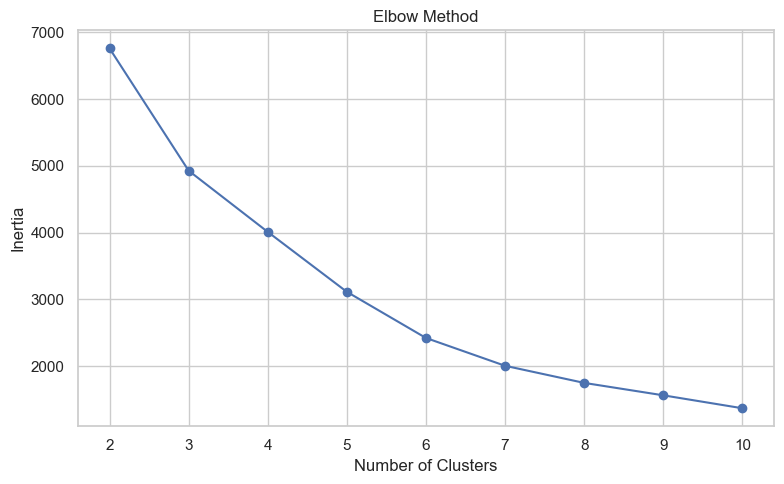

In [91]:
plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/elbow_method.png",
    dpi=300
)

plt.show()

In [92]:
# ==========================================================
# PRODUCT CLUSTERING
# ==========================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

product_df["Cluster"] = kmeans.fit_predict(
    scaled_features
)

product_df.head()

,Product Name,Total_Sales,Order_Count,Avg_Order_Value,Sales_Std,Active_Days,Cluster
0,"""While you Were Out"" Message Book, One Form pe...",25.228,3,8.409333,0.856788,3,0
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300,4,10.325000,4.344687,4,0
2,#10 Self-Seal White Envelopes,108.682,4,27.170500,26.884197,4,0
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",379.214,6,63.202333,39.514094,6,0
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,10,28.667200,15.287646,10,2


In [93]:
# ==========================================================
# BUSINESS LABELS
# ==========================================================

cluster_order = (
    product_df
    .groupby("Cluster")["Total_Sales"]
    .mean()
    .sort_values()
)

cluster_map = {
    cluster_order.index[0]: "Low Demand",
    cluster_order.index[1]: "Medium Demand",
    cluster_order.index[2]: "High Demand"
}

product_df["Segment"] = product_df["Cluster"].map(cluster_map)

product_df.head()

,Product Name,Total_Sales,Order_Count,Avg_Order_Value,Sales_Std,Active_Days,Cluster,Segment
0,"""While you Were Out"" Message Book, One Form pe...",25.228,3,8.409333,0.856788,3,0,Low Demand
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300,4,10.325000,4.344687,4,0,Low Demand
2,#10 Self-Seal White Envelopes,108.682,4,27.170500,26.884197,4,0,Low Demand
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",379.214,6,63.202333,39.514094,6,0,Low Demand
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,10,28.667200,15.287646,10,2,Medium Demand


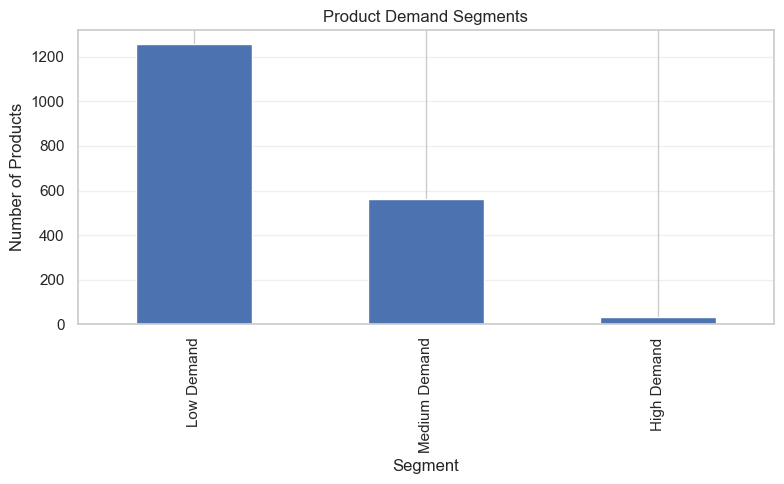

In [94]:
plt.figure(figsize=(8,5))

product_df["Segment"].value_counts().plot(kind="bar")

plt.title("Product Demand Segments")

plt.xlabel("Segment")

plt.ylabel("Number of Products")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/product_segments.png",
    dpi=300
)

plt.show()

In [95]:
segment_summary = (
    product_df
    .groupby("Segment")[
        [
            "Total_Sales",
            "Order_Count",
            "Avg_Order_Value",
            "Sales_Std",
            "Active_Days"
        ]
    ]
    .mean()
    .round(2)
)

segment_summary

,Total_Sales,Order_Count,Avg_Order_Value,Sales_Std,Active_Days
Segment,,,,,
High Demand,14778.77,4.42,4220.16,1724.61,4.39
Low Demand,629.15,3.88,185.46,83.28,3.87
Medium Demand,1802.82,8.51,229.45,134.67,8.48


## Business Insights

1. Products were segmented into High Demand, Medium Demand, and Low Demand groups using sales performance, purchasing frequency, and demand consistency.

2. High Demand products contribute the largest share of revenue and should receive priority in inventory planning and replenishment.

3. Medium Demand products are suitable candidates for targeted promotions and seasonal campaigns to increase sales.

4. Low Demand products should be reviewed for bundling, repositioning, or reduced inventory levels to optimize storage and operational costs.

5. This segmentation provides a data-driven framework for improving inventory management and supporting strategic merchandising decisions.

In [97]:
anomaly_df.to_csv(
    "outputs/anomalies.csv",
    index=False
)

In [105]:
actual = pd.DataFrame({
    "Date": test["Date"],
    "Sales": y_test.values
})

actual.to_csv("outputs/actual_sales.csv", index=False)

In [99]:
baseline_df = pd.DataFrame({
    "Date": test["Date"],
    "Prediction": baseline_pred
})

baseline_df.to_csv("outputs/baseline_forecast.csv", index=False)

In [100]:
xgb_df = pd.DataFrame({
    "Date": test["Date"],
    "Prediction": xgb_pred
})

xgb_df.to_csv("outputs/xgboost_forecast.csv", index=False)

In [101]:
prophet_df = pd.DataFrame({
    "Date": test["Date"],
    "Prediction": prophet_pred
})

prophet_df.to_csv("outputs/prophet_forecast.csv", index=False)

In [102]:
sarima_df = pd.DataFrame({
    "Date": test.index,
    "Prediction": sarima_pred.values
})

sarima_df.to_csv("outputs/sarima_forecast.csv", index=False)

In [103]:
results_df.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

In [104]:
future_forecast = forecast_30.tail(30)[
    ["ds", "yhat"]
].copy()

future_forecast.columns = [
    "Date",
    "Forecast"
]

future_forecast.to_csv(
    "outputs/future_forecast.csv",
    index=False
)

In [106]:
product_df.to_csv(
    "outputs/product_segments.csv",
    index=False
)